In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Salary Data.csv") # imported the data

In [3]:
df = df.drop_duplicates()
df = df.dropna() # dropping missing and duplicates 

In [5]:
# Encoding categorical columns

le_gender = LabelEncoder()
le_edu = LabelEncoder()
le_job = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["Education Level"] = le_edu.fit_transform(df["Education Level"])
df["Job Title"] = le_job.fit_transform(df["Job Title"])

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [6]:
# Creating features and target for prediction

X = df.drop("Salary", axis=1)
y = df["Salary"]

In [8]:
# Checking shapes 
X.shape
y.shape

('y Shape:', (324,))

In [9]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (259, 5)
X_test: (65, 5)
y_train: (259,)
y_test: (65,)


In [10]:
# Train the model 

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [11]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 10570.786401136196
MSE: 205754135.7172618
RMSE: 14344.132449097846
R2 Score: 0.8911231066517085


In [12]:
# Lets try RandomForest 
rf = RandomForestRegressor( n_estimators=100, random_state=42 )
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [13]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 9317.23076923077
MSE: 160898749.14380342
RMSE: 12684.587070291387
R2 Score: 0.9148587906175745


In [14]:
# So randomforest works better here, Now Feature importance (like which feature is most important)
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance)

               Feature  Importance
4  Years of Experience    0.511709
0                  Age    0.330297
3            Job Title    0.124331
2      Education Level    0.030731
1               Gender    0.002931


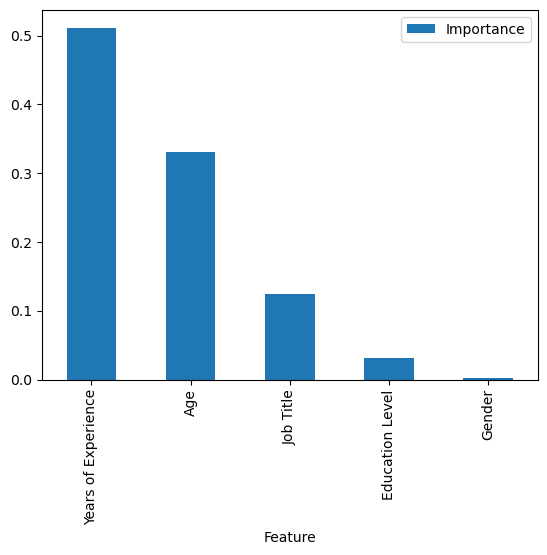

In [15]:
# Lets plot the bar chart showing importance

feature_importance.plot(x="Feature",y="Importance",kind="bar")
plt.show()

In [16]:
# Lets save the model 
pickle.dump(rf, open("salary_model.pkl", "wb"))

In [17]:
pickle.dump(le_gender, open("gender_encoder.pkl", "wb"))
pickle.dump(le_edu, open("education_encoder.pkl", "wb"))
pickle.dump(le_job, open("job_encoder.pkl", "wb"))